## **Setup**

In [1]:
# Notebook autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Path setup
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
# Libraries
import os as os
import json as json
import torch
import matplotlib.pyplot as plt

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize, dataloaders
from chatGnT.models import train

# Setup
ensure_dirs(CFG)

## **Load Tokens & Vocab**

In [4]:
with open(CFG.models_dir / "tokens_st.json", "r") as f:
    tokens_st = json.load(f)
with open(CFG.models_dir / "vocab_st.json", "r") as f:
    vocab = json.load(f)

inv_vocab = tokenize.invert_vocab_st(vocab)
tokens_padded = tokenize.encode_tokens_st(tokens_st, vocab)

In [5]:
print("Vocab ntokens:", len(vocab))
print("First 6:", list(vocab.items())[:6])
print("Last 3:", list(vocab.items())[-3:])

Vocab ntokens: 381
First 6: [('<amt>0.021 part</amt>', 1), ('<amt>0.042 part</amt>', 2), ('<amt>0.083 part</amt>', 3), ('<amt>0.167 glass</amt>', 4), ('<amt>0.167 part</amt>', 5), ('<amt>0.188 part</amt>', 6)]
Last 3: [('<ingred>yukon-jack</ingred>', 379), ('<pad>', 0), ('<end>', 380)]


In [6]:
# Convert to tensors
seqs_tensor = torch.tensor(tokens_padded, dtype=torch.long)

# Check shape: (num_recipes, seq_len)
print(seqs_tensor.shape)

torch.Size([478, 19])


## **Model Config**

In [7]:
config = {
    # model architecture
    "ntoken": len(vocab),
    "ninp": 64,  # embed size
    "nhead": 2,
    "nhid": 128,  # feed forward size
    "nlayers": 2,
    "model_version": "single_task",
    "batch_size": 16,

    # training setup
    "learning_rate": 5e-4,
    "weight_decay": 1e-2,

    # scheduler
    "scheduler_type": "reduce_on_plateau",  # "step" or "reduce_on_plateau"
    # reduce on plateau scheduler settings
    "scheduler_factor": 0.5,
    "scheduler_patience": 4,

    # token details
    "pad_id": vocab["<pad>"],

    # dataloaders
    "split": 0.85,
    "seed": 42,

    # epochs, early stopping, & logs
    "epochs": 500,
    "early_stop": 10,
    "log_interval": 6
}

## **Train Model**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = train.run_training(
    config,
    {
        "tensor": seqs_tensor,
    },
    device,
)

best_model = result["best_model"]
train_losses = result["train_losses"]
val_losses = result["val_losses"]


/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


Epoch 1 | Batch 6 | LR 0.000500 | Loss 6.9892 | PPL 1084.82 | Time 0.08s
Epoch 1 | Batch 12 | LR 0.000500 | Loss 5.8616 | PPL 351.30 | Time 0.05s
Epoch 1 | Batch 18 | LR 0.000500 | Loss 5.7493 | PPL 313.97 | Time 0.05s
Epoch 1 | Batch 24 | LR 0.000500 | Loss 5.5950 | PPL 269.07 | Time 0.05s
Epoch 1 | Batch 25 | LR 0.000500 | Loss 5.5493 | PPL 257.06 | Time 0.01s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 5.2971 | Time 0.25686192512512207 | Val PPL: 199.77
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000500 | Loss 6.3149 | PPL 552.73 | Time 0.06s
Epoch 2 | Batch 12 | LR 0.000500 | Loss 5.2853 | PPL 197.41 | Time 0.05s
Epoch 2 | Batch 18 | LR 0.000500 | Loss 5.1898 | PPL 179.44 | Time 0.05s
Epoch 2 | Batch 24 | LR 0.000500 | Loss 5.0869 | PPL 161.89 | Time 0.05s
Epoch 2 | Batch 25 | LR 0.000500 | Loss 4.9520 | PPL 141.46 | Time 0.01s
-------------------

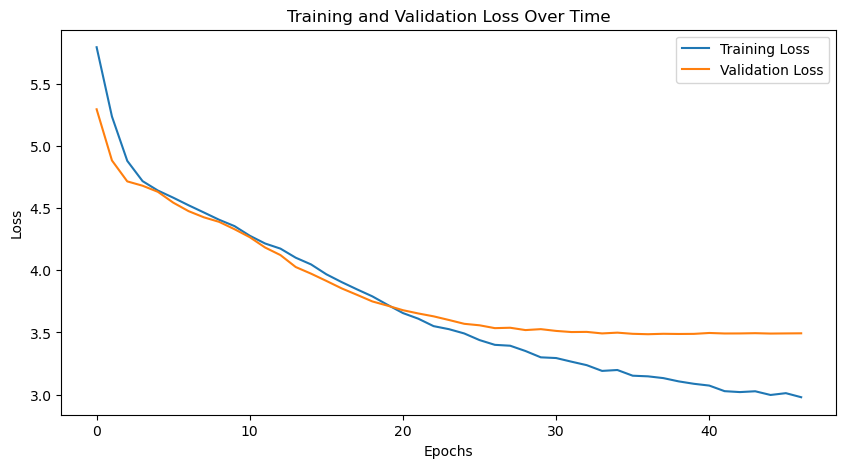

In [9]:
train.plot_training_history(train_losses, val_losses)

In [10]:
train.save_artifacts_st(best_model, config, vocab, train_losses, val_losses)
